In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kumarajarshi/life-expectancy-who/Life Expectancy Data.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

In [3]:
life_df = pd.read_csv('/kaggle/input/datasets/kumarajarshi/life-expectancy-who/Life Expectancy Data.csv')
life_df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [4]:
life_df.columns = life_df.columns.str.strip()
life_df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')

In [5]:
life_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [6]:
life_df = life_df.dropna(subset=["Life expectancy"]) # Remove a linha onde o target é nullo
X = life_df.drop(["Life expectancy", "Country", "Year"], axis=1)
y = life_df["Life expectancy"].copy()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [8]:
num_attribs = X_train.select_dtypes(include=[np.number]).columns.tolist()
num_attribs

['Adult Mortality',
 'infant deaths',
 'Alcohol',
 'percentage expenditure',
 'Hepatitis B',
 'Measles',
 'BMI',
 'under-five deaths',
 'Polio',
 'Total expenditure',
 'Diphtheria',
 'HIV/AIDS',
 'GDP',
 'Population',
 'thinness  1-19 years',
 'thinness 5-9 years',
 'Income composition of resources',
 'Schooling']

In [9]:
cat_attribs = ["Status"]

In [10]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")), # Preenche nulos com a mediana
    ('std_scaler', StandardScaler()),              # Coloca tudo na mesma escala
])

In [11]:
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])
full_pipeline

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('std_scaler',
                                                  StandardScaler())]),
                                 ['Adult Mortality', 'infant deaths', 'Alcohol',
                                  'percentage expenditure', 'Hepatitis B',
                                  'Measles', 'BMI', 'under-five deaths',
                                  'Polio', 'Total expenditure', 'Diphtheria',
                                  'HIV/AIDS', 'GDP', 'Population',
                                  'thinness  1-19 years', 'thinness 5-9 years',
                                  'Income composition of resources',
                                  'Schooling']),
                                ('cat', OneHotEncoder(), ['Status'])])

In [12]:
full_pipeline_with_predictor = Pipeline([
    ("preparation", full_pipeline),
    ("forest_reg", RandomForestRegressor())
])
full_pipeline_with_predictor

Pipeline(steps=[('preparation',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('std_scaler',
                                                                   StandardScaler())]),
                                                  ['Adult Mortality',
                                                   'infant deaths', 'Alcohol',
                                                   'percentage expenditure',
                                                   'Hepatitis B', 'Measles',
                                                   'BMI', 'under-five deaths',
                                                   'Polio', 'Total expenditure',
                                                   'Diphtheria', 'HIV/AIDS',
                                                   'GDP', 'Population',
                                                   'thinness  1-19 years',
                                                   'thinness 5-9 years',
                                                   'Income composition of '
                                                   'resources',
                                                   'Schooling']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Status'])])),
                ('forest_reg', RandomForestRegressor())])

In [13]:
nmse_scores = cross_val_score(full_pipeline_with_predictor, X_train, y_train, scoring="neg_mean_squared_error", cv=10)
rmse_scores = np.sqrt(-nmse_scores)

print(f"Média RMSE (Cross-Val): {rmse_scores.mean():.2f}")

Média RMSE (Cross-Val): 1.92


In [14]:
param_grid = [
    {'forest_reg__n_estimators': [30, 100], 
     'forest_reg__max_features': [4, 8]}
]

grid_search = GridSearchCV(full_pipeline_with_predictor, param_grid, cv=5, scoring='neg_mean_squared_error')

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preparation',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('std_scaler',
                                                                                          StandardScaler())]),
                                                                         ['Adult '
                                                                          'Mortality',
                                                                          'infant '
                                                                          'deaths',
                                                                          'Alcohol',
                                                                          'percentage '
                                                                          'expenditure',
                                                                          'Hepatitis '
                                                                          'B',
                                                                          'Measles',
                                                                          'BMI',
                                                                          'under-five '
                                                                          'deaths',
                                                                          'Polio',
                                                                          'Total '
                                                                          'expenditure',
                                                                          'Diphtheria',
                                                                          'HIV/AIDS',
                                                                          'GDP',
                                                                          'Population',
                                                                          'thinness  '
                                                                          '1-19 '
                                                                          'years',
                                                                          'thinness '
                                                                          '5-9 '
                                                                          'years',
                                                                          'Income '
                                                                          'composition '
                                                                          'of '
                                                                          'resources',
                                                                          'Schooling']),
                                                                        ('cat',
                                                                         OneHotEncoder(),
                                                                         ['Status'])])),
                                       ('forest_reg',
                                        RandomForestRegressor())]),
             param_grid=[{'forest_reg__max_features': [4, 8],
                          'forest_reg__n_estimators': [30, 100]}],
             scoring='neg_mean_squared_error')

In [15]:
grid_search.best_params_ 

{'forest_reg__max_features': 8, 'forest_reg__n_estimators': 100}

In [16]:
final_model = grid_search.best_estimator_ # X_test CRU!

In [17]:
final_predictions = final_model.predict(X_test)
final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))

print(f"RMSE Final no Teste: {final_rmse:.2f}")

RMSE Final no Teste: 1.97


# Graficos

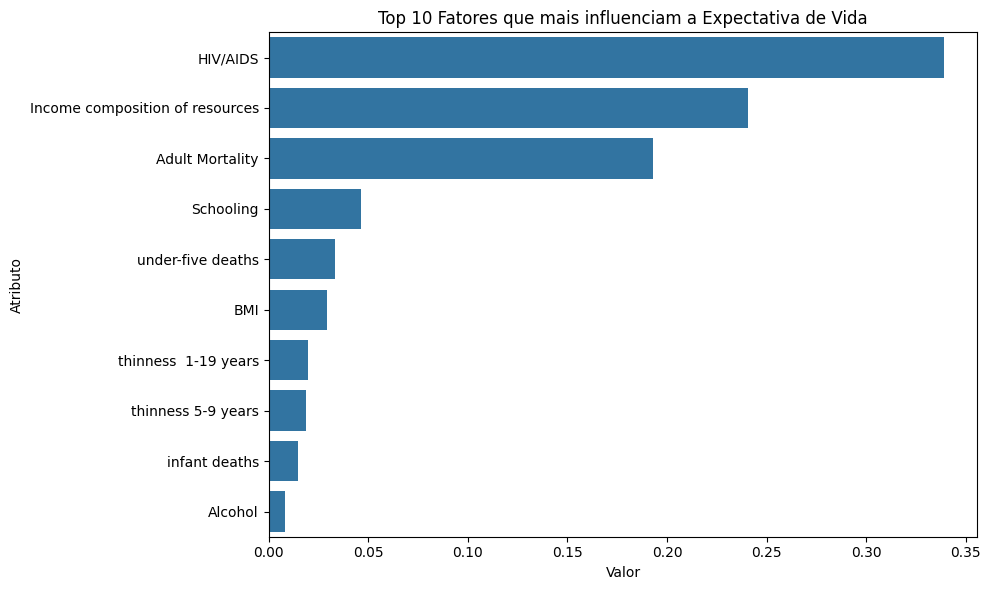

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extrair as importâncias do modelo dentro do pipeline
# O nome 'forest_reg' deve ser o mesmo que você usou no passo do Pipeline
importances = final_model.named_steps["forest_reg"].feature_importances_
attributes = num_attribs + list(final_model.named_steps["preparation"]
                                .named_transformers_["cat"]
                                .get_feature_names_out())

# Criar um DataFrame para facilitar a plotagem
feature_imp = pd.DataFrame(sorted(zip(importances, attributes), reverse=True),
                           columns=['Valor', 'Atributo'])

plt.figure(figsize=(10, 6))
sns.barplot(x="Valor", y="Atributo", data=feature_imp.head(10)) # Top 10
plt.title('Top 10 Fatores que mais influenciam a Expectativa de Vida')
plt.tight_layout()
plt.show()

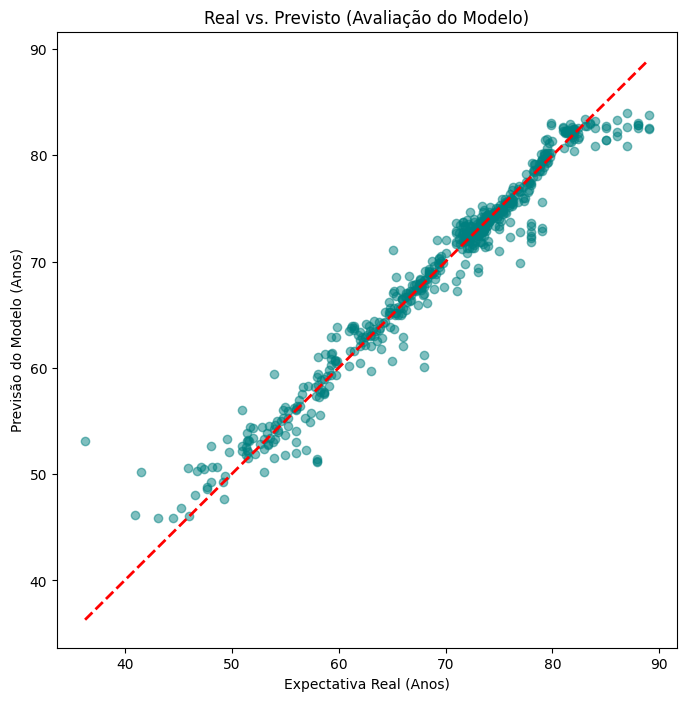

In [19]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, final_predictions, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Expectativa Real (Anos)')
plt.ylabel('Previsão do Modelo (Anos)')
plt.title('Real vs. Previsto (Avaliação do Modelo)')
plt.show()

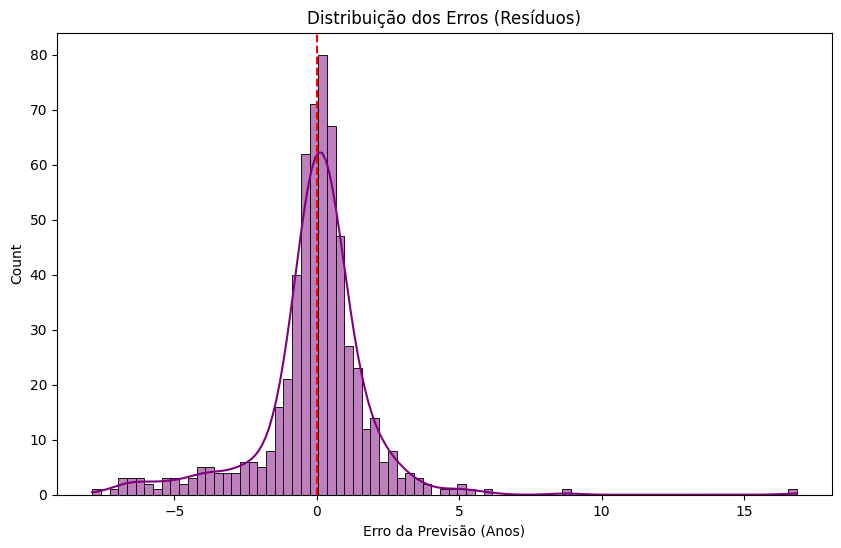

In [20]:
errors = final_predictions - y_test
plt.figure(figsize=(10, 6))
sns.histplot(errors, kde=True, color='purple')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('Erro da Previsão (Anos)')
plt.title('Distribuição dos Erros (Resíduos)')
plt.show()

# Comparando com Linear Regression

In [21]:
lin_reg = Pipeline([
    ("preparation", full_pipeline),
    ("linear", LinearRegression())
])

In [22]:
param_grid_linear = [{'linear__fit_intercept': [True, False]}]

In [23]:
grid_search_lin = GridSearchCV(lin_reg, param_grid_linear, cv=5, scoring='neg_mean_squared_error')
grid_search_lin.fit(X_train, y_train)
best_lin_model = grid_search_lin.best_estimator_

In [24]:
lin_final_rmse = np.sqrt(mean_squared_error(y_test, best_lin_model.predict(X_test)))
forest_final_rmse = np.sqrt(mean_squared_error(y_test, final_model.predict(X_test)))

In [25]:
print(f"RMSE Final Best Linear: {lin_final_rmse:.2f}")
print(f"RMSE Final Best Random Forest: {forest_final_rmse:.2f}")

RMSE Final Best Linear: 4.19
RMSE Final Best Random Forest: 1.97
